# Stage 1 — SD 2.1 LoRA Fine-tuning on SCTD + KLSG
> Teaches SD 2.1 real sonar acoustic texture using both datasets with
> domain tokens so each sonar system's appearance is learned separately.

## Workflow
1. **Cell 0** — build isolated virtualenv `sd21_stage1_env`, register kernel *(run once)*
2. Switch kernel → **Python (sd21_stage1_env)**
3. Run all remaining cells top to bottom

---

## Cell 0 — Environment setup *(run once with system kernel)*

In [ ]:
# ============================================================
# Cell 0 — Create isolated virtualenv & register Jupyter kernel
# Run ONCE with your default kernel, then switch to sd21_stage1_env
# ============================================================
import sys, subprocess, os
from pathlib import Path

VENV_DIR = Path("sd21_stage1_env").resolve()
VENV_PY  = VENV_DIR / ("Scripts/python" if os.name == "nt" else "bin/python")

# We drop VENV_PIP and use VENV_PY -m pip for structural reliability on Windows
def run_pip(*args):
    cmd = [str(VENV_PY), "-m", "pip"] + list(args)
    print("$", " ".join(str(c) for c in cmd))
    r = subprocess.run(cmd)
    if r.returncode != 0:
        raise RuntimeError(f"Failed: {cmd}")

def run(*cmd):
    print("$", " ".join(str(c) for c in cmd))
    r = subprocess.run(cmd)
    if r.returncode != 0:
        raise RuntimeError(f"Failed: {cmd}")

# ── 1. Create venv ────────────────────────────────────────────────────
if not VENV_DIR.exists():
    print("Creating virtualenv …")
    # Note: If it still fails, consider removing "--system-site-packages"
    # to guarantee absolute isolation.
    run(sys.executable, "-m", "venv", str(VENV_DIR), "--system-site-packages")
else:
    print(f"Virtualenv exists: {VENV_DIR}")

# Upgrade pip safely via python module syntax
run_pip("install", "-q", "--upgrade", "pip")

# ── 2. Pin torch to MATCH system version (avoid re-download) ─────────
torch_ver = subprocess.check_output(
    [sys.executable, "-c", "import torch; print(torch.__version__)"]
).decode().strip()
base_ver = torch_ver.split("+")[0]
print(f"System torch: {torch_ver} → pinning venv to {base_ver}")

run_pip("install", "-q",
        f"torch=={base_ver}", "torchvision",
        "--extra-index-url", "https://download.pytorch.org/whl/cu121")

# ── 3. Install diffusion + training stack ─────────────────────────────
run_pip("install", "-q",
        "diffusers>=0.27.0",
        "transformers>=4.38.0",
        "accelerate>=0.27.0",
        "peft>=0.9.0",
        "Pillow",
        "matplotlib",
        "pandas",
        "numpy",
        "scikit-learn",
        "tqdm",
        "ipykernel",
        "ipywidgets",
)

# ── 4. xformers — NO deps so torch cannot be swapped ─────────────────
run_pip("install", "-q", "xformers", "--no-deps")

# ── 5. Remove torchao if present ──────────────────────────────────────
subprocess.run([str(VENV_PY), "-m", "pip", "uninstall", "-y", "torchao"], capture_output=True)

# ── 6. Register Jupyter kernel ────────────────────────────────────────
run(str(VENV_PY), "-m", "ipykernel", "install",
    "--user", "--name", "sd21_stage1_env",
    "--display-name", "Python (sd21_stage1_env)")

# ── 7. Sanity check ───────────────────────────────────────────────────
out = subprocess.check_output([
    str(VENV_PY), "-c",
    "import torch; print(torch.__version__, '| CUDA:', torch.cuda.is_available())"
]).decode().strip()
print(f"\n✅  venv torch : {out}")
print("✅  Kernel 'sd21_stage1_env' registered")
print("\n👉  Kernel → Change Kernel → Python (sd21_stage1_env), then continue.")

Virtualenv exists: C:\Users\T1_Machine\Summer_Internship-2026\Diffusion\sd21_stage1_env
$ C:\Users\T1_Machine\Summer_Internship-2026\Diffusion\sd21_stage1_env\Scripts\python -m pip install -q --upgrade pip
System torch: 2.5.1+cu124 → pinning venv to 2.5.1
$ C:\Users\T1_Machine\Summer_Internship-2026\Diffusion\sd21_stage1_env\Scripts\python -m pip install -q torch==2.5.1 torchvision --extra-index-url https://download.pytorch.org/whl/cu121
$ C:\Users\T1_Machine\Summer_Internship-2026\Diffusion\sd21_stage1_env\Scripts\python -m pip install -q diffusers>=0.27.0 transformers>=4.38.0 accelerate>=0.27.0 peft>=0.9.0 Pillow matplotlib pandas numpy scikit-learn tqdm ipykernel ipywidgets
$ C:\Users\T1_Machine\Summer_Internship-2026\Diffusion\sd21_stage1_env\Scripts\python -m pip install -q xformers --no-deps
$ C:\Users\T1_Machine\Summer_Internship-2026\Diffusion\sd21_stage1_env\Scripts\python -m ipykernel install --user --name sd21_stage1_env --display-name Python (sd21_stage1_env)

✅  venv torch

## Cell 1 — Verify kernel & imports

In [ ]:
# ============================================================
# Cell 1 — Kernel guard + imports
# ============================================================
import sys
from pathlib import Path

# Confirm we are inside the isolated venv
VENV_DIR = Path("sd21_stage1_env").resolve()
if str(VENV_DIR) not in sys.executable:
    raise RuntimeError(
        "Wrong kernel! Go to Kernel → Change Kernel → "
        "Python (sd21_stage1_env) and re-run."
    )

import os, json, shutil, math, time
from copy import deepcopy
from datetime import datetime

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

assert torch.cuda.is_available(), "No GPU found — check CUDA drivers."

device = "cuda"
print(f"PyTorch  : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")
print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Kernel   : {sys.executable}")


PyTorch  : 2.5.1+cu121
GPU      : NVIDIA RTX 4000 Ada Generation
VRAM     : 21.5 GB
Kernel   : C:\Users\T1_Machine\Summer_Internship-2026\Diffusion\sd21_stage1_env\Scripts\python.exe


C:\Users\T1_Machine\Summer_Internship-2026\Diffusion\sd21_stage1_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 2 — Configuration

In [ ]:
# ============================================================
# Cell 2 — Configuration  ← edit paths here
# ============================================================

# ── Dataset paths ───────────────────────────────────────────
# Each dict: 'root' = folder of images, 'token' = domain prompt
# Images can live in sub-folders; rglob scans recursively.
DATASETS = [
    {
        "name"  : "SONAR",
        "root"  : "./SIM2REAL/real",    # ← single folder with all SCTD + KLSG images
        "token" : "sonar scan",
    },
]

# ── Output paths ────────────────────────────────────────────
CHECKPOINT_DIR = "./stage1_checkpoints"
SAMPLE_DIR     = "./stage1_samples"
LOG_PATH       = f"{CHECKPOINT_DIR}/training_log.json"

# ── Model ───────────────────────────────────────────────────
MODEL_ID = "sd2-community/stable-diffusion-2-1"

# ── Image ───────────────────────────────────────────────────
IMAGE_SIZE = 768        # SD 2.1 native resolution — do not lower

# ── LoRA ────────────────────────────────────────────────────
LORA_RANK    = 64       # higher capacity for large domain gap
LORA_ALPHA   = 64       # keep equal to rank for stable scaling
LORA_DROPOUT = 0.05
# Modules to train: attention (structure) + conv (texture) + projections
LORA_TARGET_MODULES = [
    "to_q", "to_k", "to_v", "to_out.0",    # attention
    "ff.net.0.proj", "ff.net.2",             # feedforward
    "conv1", "conv2",                         # resnet texture blocks
    "proj_in", "proj_out",                    # transformer projections
]

# ── Training ────────────────────────────────────────────────
BATCH_SIZE       = 1    # 768×768 + rank-64 is VRAM-heavy
GRAD_ACCUM_STEPS = 4    # effective batch = 4
NUM_EPOCHS       = 60
LR               = 2e-5
LR_WARMUP_STEPS  = 100
SAVE_EVERY       = 5    # checkpoint every N epochs
SAMPLE_EVERY     = 5    # generate sample images every N epochs
MAX_CKPTS        = 4    # keep only N most recent checkpoints

# ── Inference (for sample generation during training) ───────
SAMPLE_STEPS     = 30
SAMPLE_GUIDANCE  = 7.5
SAMPLE_STRENGTH  = 0.45  # img2img strength for held-out validation

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(SAMPLE_DIR, exist_ok=True)

print("Config ready.")
for ds in DATASETS:
    p = Path(ds['root'])
    imgs = list(p.rglob("*.jpg")) + list(p.rglob("*.jpeg")) + list(p.rglob("*.png"))
    print(f"  {ds['name']:6s}: {len(imgs):4d} images  token='{ds['token']}'  path={p}")


Config ready.
  SONAR :  938 images  token='sonar scan'  path=SIM2REAL\real


## Cell 3 — Dataset inspection

In [ ]:
# ============================================================
# Cell 3 — Dataset inspection & balance check (No-Matplotlib)
# ============================================================
import os
import random
from collections import Counter
from pathlib import Path
from PIL import Image, ImageDraw

dataset_stats = {}
all_image_records = []  # list of (path, token, dataset_name)

# 1. Traversal loop
for ds in DATASETS:
    root = Path(ds['root'])
    imgs = (list(root.rglob("*.jpg")) +
            list(root.rglob("*.jpeg")) +
            list(root.rglob("*.png")))
    dataset_stats[ds['name']] = len(imgs)
    for p in imgs:
        all_image_records.append((p, ds['token'], ds['name']))

total = len(all_image_records)
print(f"Total images : {total}")
for name, count in dataset_stats.items():
    print(f"  {name:6s} : {count:4d}  ({100*count/total:.1f}%)")

# 2. Size distribution
size_counts = Counter()
for path, _, _ in all_image_records[:200]:
    try:
        with Image.open(path) as img:
            size_counts[f"{img.width}x{img.height}"] += 1
    except Exception:
        pass
print(f"\nImage sizes (first 200 sampled): {dict(size_counts.most_common(8))}")

# ── Pure PIL Sample Grid Generation (Bypasses Matplotlib completely) ──
print("\nGenerating visual sample grid via Pillow...")
random.seed(42)
sample_records = random.sample(all_image_records, min(12, total))

# Grid settings: 2 rows, 6 columns
thumb_w, thumb_h = 200, 200
padding = 20
grid_w = (thumb_w * 6) + (padding * 7)
grid_h = (thumb_h * 2) + (padding * 3) + 40 # extra space for title

# Create a blank white canvas
grid_img = Image.new("RGB", (grid_w, grid_h), color="white")
draw = ImageDraw.Draw(grid_img)

for idx, (path, token, name) in enumerate(sample_records):
    row = idx // 6
    col = idx % 6

    # Calculate target pasting coordinates
    x = padding + col * (thumb_w + padding)
    y = padding + row * (thumb_h + padding) + 40 # offset for title row

    try:
        with Image.open(path) as img:
            # Resize image to thumbnail square safely
            img_copy = img.convert("RGB")
            img_copy.thumbnail((thumb_w, thumb_h))

            # Center the thumbnail inside its designated 200x200 block
            paste_x = x + (thumb_w - img_copy.width) // 2
            paste_y = y + (thumb_h - img_copy.height) // 2
            grid_img.paste(img_copy, (paste_x, paste_y))

            # Simple border
            draw.rectangle([paste_x, paste_y, paste_x + img_copy.width, paste_y + img_copy.height], outline="gray")
    except Exception as e:
        # Draw a placeholder red box if image loading completely fails
        draw.rectangle([x, y, x + thumb_w, y + thumb_h], fill="red")

# Ensure target directory exists and save
Path(SAMPLE_DIR).mkdir(parents=True, exist_ok=True)
output_path = Path(SAMPLE_DIR) / "dataset_sample.png"
grid_img.save(output_path)

print(f"✅ Success! Saved grid preview to: {output_path.resolve()}")

Total images : 938
  SONAR  :  938  (100.0%)

Image sizes (first 200 sampled): {'640x640': 112, '345x250': 2, '259x194': 2, '460x351': 2, '330x187': 2, '207x215': 2, '512x1024': 2, '218x231': 2}

Generating visual sample grid via Pillow...
✅ Success! Saved grid preview to: C:\Users\T1_Machine\Summer_Internship-2026\Diffusion\stage1_samples\dataset_sample.png


## Cell 4 — Dataset class & balanced dataloader

In [ ]:
# ============================================================
# Cell 4 — Dataset class with domain-token support
# Windows-safe: num_workers=0, multiprocessing spawn guard
# ============================================================
import os
import multiprocessing
from collections import Counter
from PIL import Image

# Ensure all PyTorch core components are explicitly loaded
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from transformers import CLIPTokenizer

# Windows requires spawn start method for DataLoader workers.
# Setting num_workers=0 is the safest option inside Jupyter on Windows
# (avoids BrokenPipeError / freeze that occurs with workers > 0).
NUM_WORKERS = 0 if os.name == 'nt' else 2
print(f"Platform : {'Windows' if os.name == 'nt' else 'Linux/macOS'}  "
      f"→ DataLoader num_workers={NUM_WORKERS}")


class SonarDomainDataset(Dataset):
    """
    Multi-domain sonar dataset with per-image domain tokens.
    Balances datasets so neither dominates training regardless of size.
    """
    def __init__(self, image_records, tokenizer, size=768, augment=True):
        """
        image_records : list of (Path, token_str, dataset_name)
        tokenizer     : CLIP tokenizer from the loaded model
        size          : resize target (768 for SD 2.1)
        augment       : apply sonar-safe augmentations
        """
        self.records   = image_records
        self.tokenizer = tokenizer
        self.size      = size

        # ── Sonar-safe augmentations ──────────────────────────────
        # No color jitter  → sonar is grayscale-like, jitter is meaningless
        # No cutout        → would randomly erase targets, corrupts labels
        # No heavy persp.  → creates physically impossible sonar geometry
        aug_list = [transforms.Resize((size, size))]
        if augment:
            aug_list += [
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.2),
                transforms.RandomRotation(degrees=10),
                transforms.RandomAutocontrast(p=0.3),       # sonar gain variation
                transforms.RandomAdjustSharpness(           # sonar focus variation
                    sharpness_factor=1.5, p=0.3),
            ]
        aug_list += [
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),  # → [-1, 1]
        ]
        self.transform = transforms.Compose(aug_list)

        # ── Per-sample weights for balanced sampling ──────────────
        # Each dataset gets equal total weight regardless of its size.
        name_counts = Counter(r[2] for r in self.records)
        n_datasets  = len(name_counts)
        self.sample_weights = [
            1.0 / (name_counts[r[2]] * n_datasets)
            for r in self.records
        ]

        print(f"Dataset  : {len(self.records)} images across {n_datasets} domains")
        for name, count in name_counts.items():
            print(f"  {name:8s}: {count} images")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        path, token, name = self.records[idx]

        # Load image — convert to RGB so grayscale PNGs get 3 channels cleanly
        img = Image.open(path).convert("RGB")
        pixel_values = self.transform(img)

        # Tokenize domain prompt at load time (keeps training loop clean)
        # Using [0] index instead of squeeze(0) ensures structural safety
        token_ids = self.tokenizer(
            str(token),  # Cast to string to avoid tokenization errors
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        ).input_ids[0]

        return {
            "pixel_values" : pixel_values,
            "input_ids"    : token_ids,
            "domain"       : name,
            "path"         : str(path),
        }


# ── Load tokenizer ────────────────────────────────────────────────────

# Added fallbacks for safety if notebook states were cleared
MODEL_ID = globals().get("MODEL_ID", "sd2-community/stable-diffusion-2-1")
IMAGE_SIZE = globals().get("IMAGE_SIZE", 768)
BATCH_SIZE = globals().get("BATCH_SIZE", 4)
GRAD_ACCUM_STEPS = globals().get("GRAD_ACCUM_STEPS", 1)
NUM_EPOCHS = globals().get("NUM_EPOCHS", 10)
device = globals().get("device", "cuda" if torch.cuda.is_available() else "cpu")
all_image_records = globals().get("all_image_records", [])

tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")
print(f"Tokenizer: max_length={tokenizer.model_max_length}")

# ── Build dataset ─────────────────────────────────────────────────────
if len(all_image_records) == 0:
    print("⚠️ Warning: 'all_image_records' is empty. Populate it before creating DataLoader.")
else:
    train_dataset = SonarDomainDataset(
        all_image_records, tokenizer, size=IMAGE_SIZE, augment=True
    )

    # Balanced weighted sampler
    sampler = WeightedRandomSampler(
        weights=train_dataset.sample_weights,
        num_samples=len(train_dataset),
        replacement=True,
    )

    # ── DataLoader ────────────────────────────────────────────────────
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,   # 0 on Windows
        pin_memory=(device == 'cuda'),
        drop_last=True,
        persistent_workers=False,  # Must be False when num_workers=0
    )

    print(f"\nBatches per epoch : {len(train_loader)}")
    print(f"Effective batch   : {BATCH_SIZE * GRAD_ACCUM_STEPS}")
    print(f"Estimated steps   : {len(train_loader) * NUM_EPOCHS}")

Platform : Windows  → DataLoader num_workers=0
Tokenizer: max_length=77
Dataset  : 938 images across 1 domains
  SONAR   : 938 images

Batches per epoch : 938
Effective batch   : 4
Estimated steps   : 56280


## Cell 5 — Load SD 2.1 model components

In [ ]:
import site
for p in site.getsitepackages():
    print(p)

C:\Users\T1_Machine\Summer_Internship-2026\Diffusion\sd21_stage1_env
C:\Users\T1_Machine\Summer_Internship-2026\Diffusion\sd21_stage1_env\Lib\site-packages
C:\Users\T1_Machine\anaconda3
C:\Users\T1_Machine\anaconda3\Lib\site-packages


In [ ]:
# ============================================================
# Cell 5 — Load SD 2.1 model components
# ============================================================
from diffusers import DDPMScheduler, AutoencoderKL, UNet2DConditionModel
from transformers import CLIPTextModel

print("Loading VAE …")
vae = AutoencoderKL.from_pretrained(
    MODEL_ID, subfolder="vae",
    torch_dtype=torch.float16
).to(device)

print("Loading text encoder …")
text_encoder = CLIPTextModel.from_pretrained(
    MODEL_ID, subfolder="text_encoder",
    torch_dtype=torch.float16
).to(device)

print("Loading UNet …")
unet = UNet2DConditionModel.from_pretrained(
    MODEL_ID, subfolder="unet",
    torch_dtype=torch.float32  # train in fp32 for stability
).to(device)

print("Loading noise scheduler …")
noise_scheduler = DDPMScheduler.from_pretrained(
    MODEL_ID, subfolder="scheduler"
)

# ── Freeze VAE and text encoder completely ────────────────────────────
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

# ── Enable memory-efficient attention if xformers available ──────────
try:
    unet.enable_xformers_memory_efficient_attention()
    print("xformers memory-efficient attention: enabled")
except Exception:
    print("xformers not available — using default attention")

# ── Enable gradient checkpointing (saves ~30% VRAM at 768px) ─────────
unet.enable_gradient_checkpointing()

total_params = sum(p.numel() for p in unet.parameters()) / 1e6
print(f"\nUNet parameters : {total_params:.0f}M")
print("VAE + text encoder: frozen")


Loading VAE …
Loading text encoder …
Loading UNet …
Loading noise scheduler …
xformers not available — using default attention

UNet parameters : 866M
VAE + text encoder: frozen


## Cell 6 — Apply LoRA to UNet

In [ ]:
# ============================================================
# Cell 6 — Apply LoRA adapters to UNet
# ============================================================
from peft import LoraConfig, get_peft_model

# Filter target modules to only those actually present in SD 2.1 UNet
unet_module_names = {name for name, _ in unet.named_modules()}

def module_exists(target):
    """Check if any UNet module name ends with the target suffix."""
    return any(name.endswith(target) for name in unet_module_names)

valid_targets = [m for m in LORA_TARGET_MODULES if module_exists(m)]
skipped       = [m for m in LORA_TARGET_MODULES if not module_exists(m)]

if skipped:
    print(f"Modules not found in UNet (skipped): {skipped}")

lora_config = LoraConfig(
    r              = LORA_RANK,
    lora_alpha     = LORA_ALPHA,
    target_modules = valid_targets,
    lora_dropout   = LORA_DROPOUT,
    bias           = "none",
)

unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

# ── Parameter breakdown ───────────────────────────────────────────────
trainable   = sum(p.numel() for p in unet.parameters() if p.requires_grad)
total_unet  = sum(p.numel() for p in unet.parameters())
print(f"\nLoRA modules applied : {len(valid_targets)}")
print(f"Trainable params     : {trainable/1e6:.2f}M / {total_unet/1e6:.0f}M "
      f"({100*trainable/total_unet:.2f}%)")


trainable params: 58,990,592 || all params: 924,901,316 || trainable%: 6.3780

LoRA modules applied : 10
Trainable params     : 58.99M / 925M (6.38%)


## Cell 7 — Optimizer & LR scheduler

In [ ]:
# ============================================================
# Cell 7 — Optimizer and LR scheduler with warmup
# ============================================================
from torch.optim.lr_scheduler import LambdaLR

trainable_params = [p for p in unet.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LR,
    betas=(0.9, 0.999),
    weight_decay=1e-2,
    eps=1e-8,
)

total_steps  = (len(train_loader) // GRAD_ACCUM_STEPS) * NUM_EPOCHS
warmup_steps = LR_WARMUP_STEPS

def lr_lambda(current_step):
    """Linear warmup then cosine decay."""
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / \
               float(max(1, total_steps - warmup_steps))
    return max(1e-7, 0.5 * (1.0 + math.cos(math.pi * progress)))

lr_scheduler = LambdaLR(optimizer, lr_lambda)

print(f"Optimizer     : AdamW  lr={LR}  wd=1e-2")
print(f"LR schedule   : linear warmup ({warmup_steps} steps) → cosine decay")
print(f"Total steps   : {total_steps}")
print(f"Warmup steps  : {warmup_steps}")


Optimizer     : AdamW  lr=2e-05  wd=1e-2
LR schedule   : linear warmup (100 steps) → cosine decay
Total steps   : 14040
Warmup steps  : 100


## Cell 8 — Checkpoint helpers

In [ ]:
# ============================================================
# Cell 8 — Checkpoint save / resume helpers
# ============================================================
from safetensors.torch import load_file as load_safetensors

def save_checkpoint(unet, optimizer, lr_scheduler,
                    epoch, global_step, loss_history):
    tag      = f"epoch_{epoch:03d}"
    ckpt_dir = Path(CHECKPOINT_DIR) / tag
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    unet.save_pretrained(str(ckpt_dir))

    torch.save({
        "epoch"        : epoch,
        "global_step"  : global_step,
        "optimizer"    : optimizer.state_dict(),
        "lr_scheduler" : lr_scheduler.state_dict(),
    }, ckpt_dir / "trainer_state.pt")

    with open(LOG_PATH, "w") as fh:
        json.dump(loss_history, fh, indent=2)

    all_ckpts = sorted([
        d for d in os.listdir(CHECKPOINT_DIR)
        if d.startswith("epoch_")
    ])
    while len(all_ckpts) > MAX_CKPTS:
        shutil.rmtree(Path(CHECKPOINT_DIR) / all_ckpts.pop(0))

    print(f"  ✓ Checkpoint saved → {tag}")
    return str(ckpt_dir)


def find_latest_checkpoint():
    ckpts = sorted([
        d for d in os.listdir(CHECKPOINT_DIR)
        if d.startswith("epoch_")
    ])
    if not ckpts:
        return None, -1, 0

    latest     = ckpts[-1]
    last_epoch = int(latest.replace("epoch_", ""))
    state_path = Path(CHECKPOINT_DIR) / latest / "trainer_state.pt"

    global_step = 0
    if state_path.exists():
        state = torch.load(state_path, map_location="cpu", weights_only=False)
        global_step = state.get("global_step", 0)

    return str(Path(CHECKPOINT_DIR) / latest), last_epoch, global_step


def load_checkpoint(unet, optimizer, lr_scheduler):
    ckpt_path, last_epoch, global_step = find_latest_checkpoint()
    if ckpt_path is None:
        print("No checkpoint found — starting from scratch.")
        return -1, 0, []

    print(f"Resuming from checkpoint: {ckpt_path}")

    from peft import set_peft_model_state_dict

    sf_path  = Path(ckpt_path) / "adapter_model.safetensors"
    bin_path = Path(ckpt_path) / "adapter_model.bin"

    if sf_path.exists():
        state_dict = load_safetensors(str(sf_path))
    elif bin_path.exists():
        state_dict = torch.load(bin_path, map_location=device, weights_only=True)
    else:
        raise FileNotFoundError(f"No adapter weights found in {ckpt_path}")

    set_peft_model_state_dict(unet, state_dict)

    state_path = Path(ckpt_path) / "trainer_state.pt"
    if state_path.exists():
        state = torch.load(state_path, map_location="cpu", weights_only=False)
        optimizer.load_state_dict(state["optimizer"])
        lr_scheduler.load_state_dict(state["lr_scheduler"])

    loss_history = []
    if Path(LOG_PATH).exists():
        with open(LOG_PATH) as fh:
            loss_history = json.load(fh)

    print(f"  Resumed epoch {last_epoch}, global step {global_step}")
    return last_epoch, global_step, loss_history


print("Checkpoint helpers defined.")

Checkpoint helpers defined.


## Cell 9 — Sample generation helper

In [ ]:
# ============================================================
# Cell 9 — Sample generation during training (img2img)
# Generates one sample per domain token using held-out images
# ============================================================
from diffusers import StableDiffusionImg2ImgPipeline
from peft import PeftModel
from safetensors.torch import load_file as load_safetensors

# Pick one held-out image per domain for visual quality tracking
HELD_OUT = {}
for ds in DATASETS:
    root = Path(ds['root'])
    imgs = (list(root.rglob("*.jpg")) + list(root.rglob("*.png")))
    if imgs:
        HELD_OUT[ds['name']] = {"path": imgs[-1], "token": ds['token']}
        print(f"Held-out ({ds['name']}): {imgs[-1].name}")


def _ensure_bin_checkpoint(ckpt_path):
    """PeftModel.from_pretrained expects adapter_model.bin in some peft
    versions. If only .safetensors exists, create a .bin copy."""
    ckpt = Path(ckpt_path)
    bin_path = ckpt / "adapter_model.bin"
    sf_path  = ckpt / "adapter_model.safetensors"
    if not bin_path.exists() and sf_path.exists():
        state_dict = load_safetensors(str(sf_path))
        torch.save(state_dict, bin_path)


def generate_samples(unet_model, epoch):
    """
    Generate img2img samples from held-out images using current LoRA weights.
    Saves a comparison grid: original | generated.
    """
    unet_model.eval()

    pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        safety_checker=None,
        requires_safety_checker=False,
    ).to(device)

    latest_ckpt, _, _ = find_latest_checkpoint()
    if latest_ckpt:
        _ensure_bin_checkpoint(latest_ckpt)
        pipe.unet = PeftModel.from_pretrained(pipe.unet, latest_ckpt)
        pipe.unet = pipe.unet.merge_and_unload()

    try:
        pipe.enable_xformers_memory_efficient_attention()
    except Exception:
        pass

    n_domains = len(HELD_OUT)
    fig, axes = plt.subplots(n_domains, 2, figsize=(10, 5 * n_domains))
    if n_domains == 1:
        axes = [axes]

    for row_idx, (domain_name, info) in enumerate(HELD_OUT.items()):
        orig = Image.open(info['path']).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))

        with torch.no_grad():
            gen = pipe(
                prompt=info['token'],
                image=orig,
                strength=SAMPLE_STRENGTH,
                guidance_scale=SAMPLE_GUIDANCE,
                num_inference_steps=SAMPLE_STEPS,
                generator=torch.Generator(device).manual_seed(42),
            ).images[0]

        axes[row_idx][0].imshow(orig, cmap="gray")
        axes[row_idx][0].set_title(f"{domain_name} — ORIGINAL", fontsize=10, color="blue")
        axes[row_idx][0].axis("off")

        axes[row_idx][1].imshow(gen, cmap="gray")
        axes[row_idx][1].set_title(f"{domain_name} — LoRA epoch {epoch}", fontsize=10, color="green")
        axes[row_idx][1].axis("off")

    plt.suptitle(f"Stage 1 Quality Check — Epoch {epoch}", fontsize=13)
    plt.tight_layout()
    out_path = f"{SAMPLE_DIR}/epoch_{epoch:03d}_samples.png"
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Sample grid saved → {out_path}")

    del pipe
    torch.cuda.empty_cache()
    unet_model.train()


print("Sample generator ready.")

Held-out (SONAR): 000686_jpg.rf.2607951aa62c8eae9a9ce7a12f59f21a.jpg
Sample generator ready.


## Cell 10 — Training loop

Resuming from checkpoint: stage1_checkpoints\epoch_020
  Resumed epoch 20, global step 4914

Training: epoch 21 → 60
Steps per epoch : 938
Est. time remaining: ~500 min



Epoch  21/60  loss=0.1591  lr=1.42e-05  [SONAR=0.1591]


Epoch  22/60  loss=0.1748  lr=1.37e-05  [SONAR=0.1748]


Epoch  23/60  loss=0.1691  lr=1.32e-05  [SONAR=0.1691]


Epoch  24/60  loss=0.1606  lr=1.27e-05  [SONAR=0.1606]


Epoch  25/60  loss=0.1749  lr=1.22e-05  [SONAR=0.1749]
  ✓ Checkpoint saved → epoch_025


100%|██████████| 13/13 [00:01<00:00,  8.63it/s]


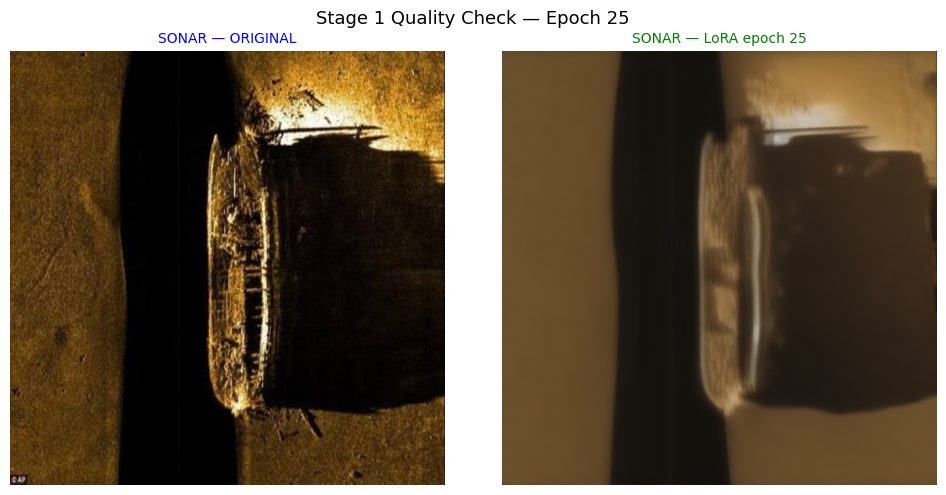

  ✓ Sample grid saved → ./stage1_samples/epoch_025_samples.png


Epoch  26/60  loss=0.1703  lr=1.17e-05  [SONAR=0.1703]


Epoch  27/60  loss=0.1651  lr=1.12e-05  [SONAR=0.1651]


Epoch  28/60  loss=0.1825  lr=1.06e-05  [SONAR=0.1825]


Epoch  29/60  loss=0.1712  lr=1.01e-05  [SONAR=0.1712]


Epoch  30/60  loss=0.1651  lr=9.59e-06  [SONAR=0.1651]
  ✓ Checkpoint saved → epoch_030


100%|██████████| 13/13 [00:01<00:00,  8.56it/s]


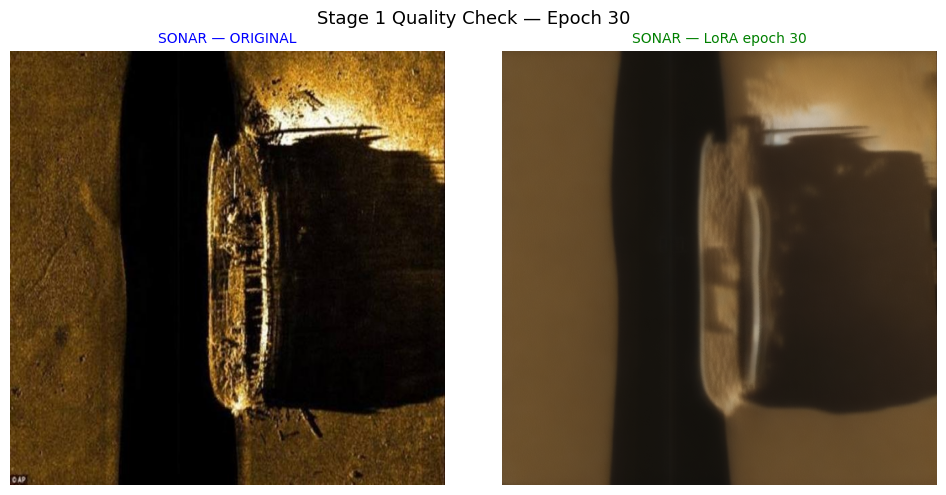

  ✓ Sample grid saved → ./stage1_samples/epoch_030_samples.png


Epoch  31/60  loss=0.1730  lr=9.06e-06  [SONAR=0.1730]


Epoch  32/60  loss=0.1714  lr=8.54e-06  [SONAR=0.1714]


Epoch  33/60  loss=0.1647  lr=8.02e-06  [SONAR=0.1647]


Epoch  34/60  loss=0.1643  lr=7.50e-06  [SONAR=0.1643]


Epoch  35/60  loss=0.1795  lr=7.00e-06  [SONAR=0.1795]
  ✓ Checkpoint saved → epoch_035


100%|██████████| 13/13 [00:01<00:00,  8.66it/s]


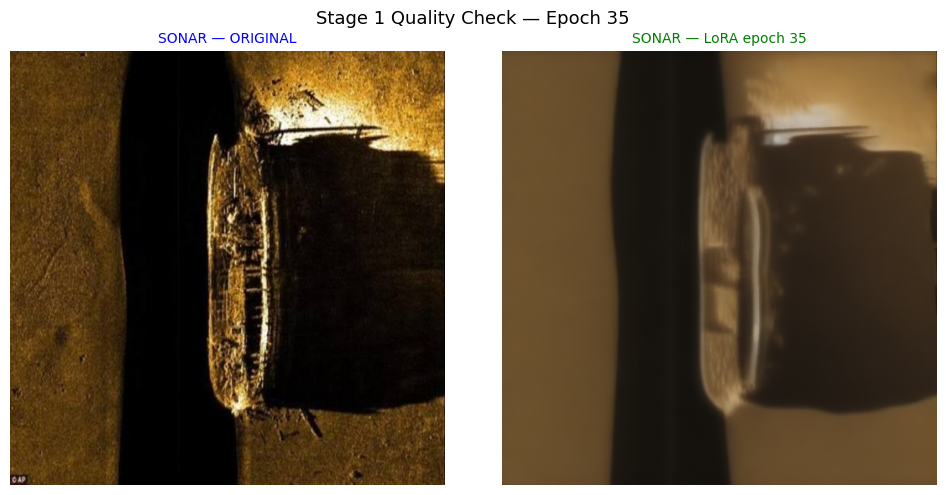

  ✓ Sample grid saved → ./stage1_samples/epoch_035_samples.png


Epoch  36/60  loss=0.1762  lr=6.50e-06  [SONAR=0.1762]


Epoch  37/60  loss=0.1754  lr=6.01e-06  [SONAR=0.1754]


Epoch  38/60  loss=0.1774  lr=5.53e-06  [SONAR=0.1774]


Epoch  39/60  loss=0.1720  lr=5.07e-06  [SONAR=0.1720]


Epoch  40/60  loss=0.1765  lr=4.61e-06  [SONAR=0.1765]
  ✓ Checkpoint saved → epoch_040


100%|██████████| 13/13 [00:01<00:00,  8.55it/s]


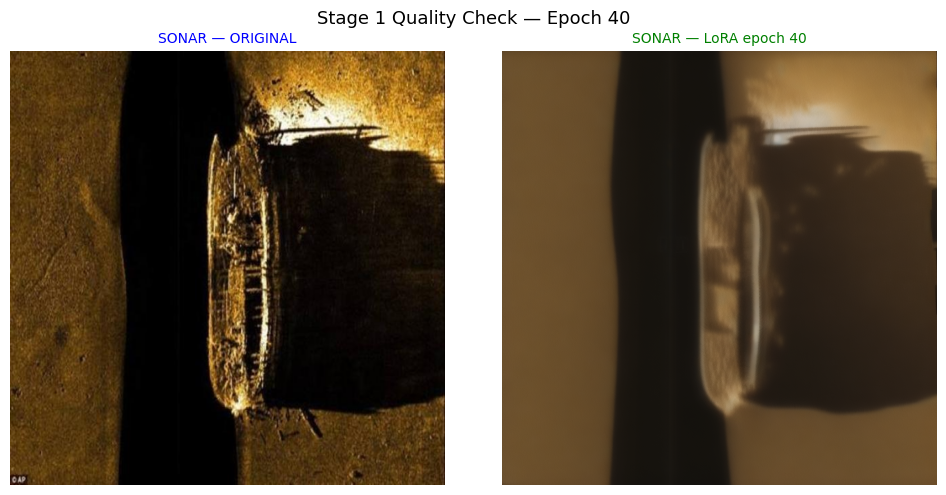

  ✓ Sample grid saved → ./stage1_samples/epoch_040_samples.png


Epoch  41/60  loss=0.1758  lr=4.18e-06  [SONAR=0.1758]


Epoch  42/60:  84%|████████▍ | 788/938 [14:06<02:41,  1.07s/it, loss=0.1220, lr=3.82e-06]

In [ ]:
# ============================================================
# Cell 10 — Main training loop
# Supports resume from checkpoint automatically
# ============================================================

# ── Resume if checkpoint exists ───────────────────────────────────────
start_epoch, global_step, loss_history = load_checkpoint(
    unet, optimizer, lr_scheduler
)
start_epoch += 1  # next epoch after last saved

domain_loss_history = {ds['name']: [] for ds in DATASETS}

print(f"\nTraining: epoch {start_epoch} → {NUM_EPOCHS}")
print(f"Steps per epoch : {len(train_loader)}")
total_epochs_left = NUM_EPOCHS - start_epoch + 1
mins_per_epoch = len(train_loader) * BATCH_SIZE * 0.8 / 60
print(f"Est. time remaining: ~{total_epochs_left * mins_per_epoch:.0f} min\n")

# ── Training loop ─────────────────────────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    unet.train()
    epoch_loss   = 0.0
    domain_loss  = {ds['name']: [] for ds in DATASETS}
    n_batches    = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:3d}/{NUM_EPOCHS}",
                leave=False)

    for step, batch in enumerate(pbar):
        pixel_values = batch["pixel_values"].to(device, dtype=torch.float16)
        input_ids    = batch["input_ids"].to(device)
        domains      = batch["domain"]

        # ── Encode image to latents ──────────────────────────────
        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = (latents * vae.config.scaling_factor).float()

        # ── Encode text (domain token) ───────────────────────────
        with torch.no_grad():
            text_embeddings = text_encoder(input_ids).last_hidden_state
            text_embeddings = text_embeddings.float()

        # ── Add noise ────────────────────────────────────────────
        noise = torch.randn_like(latents)
        t = torch.randint(
            0, noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],), device=device
        ).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, t)

        # ── Predict noise ─────────────────────────────────────────
        noise_pred = unet(
            noisy_latents, t,
            encoder_hidden_states=text_embeddings
        ).sample

        # ── Compute loss ─────────────────────────────────────────
        loss = F.mse_loss(noise_pred, noise, reduction="mean")
        scaled_loss = loss / GRAD_ACCUM_STEPS
        scaled_loss.backward()

        # Track per-domain loss
        loss_val = loss.item()
        for d in set(domains):
            domain_loss[d].append(loss_val)

        # ── Gradient accumulation step ────────────────────────────
        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(
                trainable_params, max_norm=1.0
            )
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            global_step += 1

        epoch_loss += loss_val
        n_batches  += 1

        current_lr = lr_scheduler.get_last_lr()[0]
        pbar.set_postfix({
            "loss": f"{loss_val:.4f}",
            "lr"  : f"{current_lr:.2e}",
        })

    # ── Epoch summary ─────────────────────────────────────────────────
    avg_loss = epoch_loss / max(n_batches, 1)
    current_lr = lr_scheduler.get_last_lr()[0]

    domain_avgs = {
        d: (sum(v)/len(v) if v else 0.0)
        for d, v in domain_loss.items()
    }

    epoch_record = {
        "epoch"       : epoch,
        "loss"        : avg_loss,
        "lr"          : current_lr,
        "global_step" : global_step,
        "domain_loss" : domain_avgs,
        "timestamp"   : datetime.now().isoformat(),
    }
    loss_history.append(epoch_record)

    domain_str = "  ".join(
        f"{d}={v:.4f}" for d, v in domain_avgs.items()
    )
    print(f"Epoch {epoch:3d}/{NUM_EPOCHS}  "
          f"loss={avg_loss:.4f}  lr={current_lr:.2e}  "
          f"[{domain_str}]")

    # ── Checkpoint ────────────────────────────────────────────────────
    if epoch % SAVE_EVERY == 0 or epoch == NUM_EPOCHS:
        save_checkpoint(
            unet, optimizer, lr_scheduler,
            epoch, global_step, loss_history
        )

    # ── Visual samples ────────────────────────────────────────────────
    if epoch % SAMPLE_EVERY == 0 or epoch == NUM_EPOCHS:
        generate_samples(unet, epoch)

print("\n✅  Training complete.")


## Cell 11 — Training loss analysis

In [ ]:
if Path(LOG_PATH).exists() and not loss_history:
    with open(LOG_PATH) as fh:
        loss_history = json.load(fh)

epochs   = [r['epoch'] for r in loss_history]
losses   = [r['loss']  for r in loss_history]
lrs      = [r['lr']    for r in loss_history]

# Per-domain losses
domain_names = list(loss_history[0].get('domain_loss', {}).keys())
domain_losses = {
    d: [r.get('domain_loss', {}).get(d, None) for r in loss_history]
    for d in domain_names
}

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ── Total loss ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs, losses, 'b-o', markersize=3, label='Total')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE Loss')
ax1.set_title('Total Training Loss')
ax1.grid(True, alpha=0.3); ax1.legend()

# ── Per-domain loss ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i, (d, dloss) in enumerate(domain_losses.items()):
    valid = [(e, l) for e, l in zip(epochs, dloss) if l is not None]
    if valid:
        ex, lx = zip(*valid)
        ax2.plot(ex, lx, '-o', markersize=3,
                 color=colors[i % len(colors)], label=d)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE Loss')
ax2.set_title('Loss per Domain')
ax2.grid(True, alpha=0.3); ax2.legend()

# ── Learning rate ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(epochs, lrs, 'g-o', markersize=3)
ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR')
ax3.set_title('Learning Rate Schedule')
ax3.grid(True, alpha=0.3)

plt.suptitle('Stage 1 — SD 2.1 LoRA Training Summary', fontsize=13)
plt.tight_layout()
out = f"{SAMPLE_DIR}/training_summary.png"
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved {out}")

# ── Domain balance check ──────────────────────────────────────────────
print("\nDomain loss convergence check (last 5 epochs):")
for d in domain_names:
    recent = [l for l in domain_losses[d][-5:] if l is not None]
    if recent:
        print(f"  {d:8s}: mean={sum(recent)/len(recent):.4f}  "
              f"last={recent[-1]:.4f}")


## Cell 14 — Export final LoRA weights

In [ ]:
# ============================================================
# Cell 14 — Export final LoRA for use in Stage 2 / inference
# ============================================================
EXPORT_DIR = "./stage1_lora_final"
os.makedirs(EXPORT_DIR, exist_ok=True)

# Save LoRA adapter weights
unet.save_pretrained(EXPORT_DIR)

# Save domain token registry so Stage 2 knows which tokens to use
token_registry = {
    "model_id"   : MODEL_ID,
    "image_size" : IMAGE_SIZE,
    "lora_rank"  : LORA_RANK,
    "domains"    : [
        {"name": ds["name"], "token": ds["token"]}
        for ds in DATASETS
    ],
    "trained_epochs" : NUM_EPOCHS,
    "final_loss"     : loss_history[-1]['loss'] if loss_history else None,
    "exported_at"    : datetime.now().isoformat(),
}
with open(f"{EXPORT_DIR}/token_registry.json", "w") as fh:
    json.dump(token_registry, fh, indent=2)

# Save training summary plot alongside weights
summary_plot = f"{SAMPLE_DIR}/training_summary.png"
if Path(summary_plot).exists():
    shutil.copy(summary_plot, f"{EXPORT_DIR}/training_summary.png")

print("Stage 1 LoRA exported to:", EXPORT_DIR)
print("Files:")
for f in sorted(Path(EXPORT_DIR).iterdir()):
    print(f"  {f.name}")
print("\nToken registry:")
print(json.dumps(token_registry, indent=2))


In [ ]:
import subprocess, shutil
subprocess.run(["jupyter", "kernelspec", "remove", "-f", "sd21_stage1_env"])
shutil.rmtree("sd21_stage1_env", ignore_errors=True)
print("Environment removed.")


Environment removed.
